
# Simulating the Income Distribution — Life-Cycle Model

This notebook implements and analyses the life-cycle model described in
Section 2 of the assignment. All model logic lives in the documented module
`life_cycle.py`, which is imported below.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import life_cycle as lc
from life_cycle import Params, simulate, gini, lorenz_curve

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pd.set_option("display.precision", 4)
np.set_printoptions(precision=4, suppress=True)


## 2.2.1 Baseline simulation and sanity checks

**What we do:** We simulate $N=50{,}000$ individuals through their whole working life
(age 18-64) using `simulate(Params())`, i.e. the model with all default
parameters. Before trusting anything else, we start out by checking two things:

1. Do the realized shares of short/medium/long education match the targets
   we set $p_e = (0.40, 0.35, 0.25)$?
2. Does unemployment settle at the theoretical steady state $\sigma/(\sigma+\lambda)$ given from the assignment 
  
**How:** We group the panel by `education` and divide by the total number of
unique `id`s to get realized shares. For unemployment, we restrict to rows
where `in_education` is `False`, group by `age`, and take `1 - mean(employed)`
to get the unemployment rate at each age.
  
**Why:** The simulation is complex enough that a bug or a fail-40 can easily hide, such as a
flipped sign, a probability used the wrong way round, etc. If the model
*doesn't* hit these two known "truths", there's no reason to trust anything
else that comes out of it. This is pure debugging beforehand, not really part of
answering the question, but without it we wouldn't know whether we're
analyzing a correct model or a bug.

In [2]:
baseline = simulate(Params())

edu_shares = baseline.groupby("education")["id"].nunique() / baseline["id"].nunique()
edu_shares = edu_shares.reindex(["short", "medium", "long"])
print("Realised education shares vs targets (0.40, 0.35, 0.25):")
print(edu_shares.rename("share").to_frame().assign(target=[0.40, 0.35, 0.25]))

working = baseline[~baseline["in_education"]]
unemp_by_age = working.groupby("age")["employed"].apply(lambda s: 1 - s.mean())
unemp_by_age.name = "unemployment_rate"
steady_state = 0.05 / (0.05 + 0.60)
print(f"\nTheoretical steady-state unemployment rate sigma/(sigma+lambda) = {steady_state:.4f}")
print("Average unemployment rate over the last 15 working ages (should be close):")
print(f"  {unemp_by_age.iloc[-15:].mean():.4f}")
print("\nUnemployment rate right after labour-market entry is much higher because")
print("everybody starts out unemployed by construction; it then decays towards")
print("the steady state as the Markov chain mixes:")
print(unemp_by_age.head(8).round(4))

Realised education shares vs targets (0.40, 0.35, 0.25):
            share  target
education                
short      0.4040    0.40
medium     0.3503    0.35
long       0.2457    0.25

Theoretical steady-state unemployment rate sigma/(sigma+lambda) = 0.0769
Average unemployment rate over the last 15 working ages (should be close):
  0.0755

Unemployment rate right after labour-market entry is much higher because
everybody starts out unemployed by construction; it then decays towards
the steady state as the Markov chain mixes:
age
19    1.0000
20    0.3951
21    0.5649
22    0.2478
23    0.3500
24    0.1739
25    0.1111
26    0.0909
Name: unemployment_rate, dtype: float64


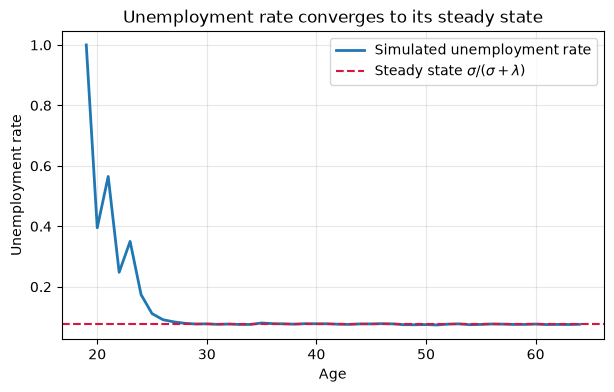

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(unemp_by_age.index, unemp_by_age.values, lw=2, label="Simulated unemployment rate")
ax.axhline(steady_state, color="crimson", ls="--", label=r"Steady state $\sigma/(\sigma+\lambda)$")
ax.set_xlabel("Age")
ax.set_ylabel("Unemployment rate")
ax.set_title("Unemployment rate converges to its steady state")
ax.legend()
plt.show()


Both checks pass: education shares match the targets to within simulation
noise, and the unemployment rate converges quickly (within a few years of
labour-market entry) to the theoretical steady state of about **7.7%**.


## 2.2.2 Mean and percentiles of income over the life cycle
Mean and 5 percentiles of income by age, to see when in life inequality
appears and how it grows.

**How:** `groupby("age")["income"]`, then `.mean()` and `.quantile(p/100)`
per percentile into `stats_by_age`, one line per statistic on the plot.

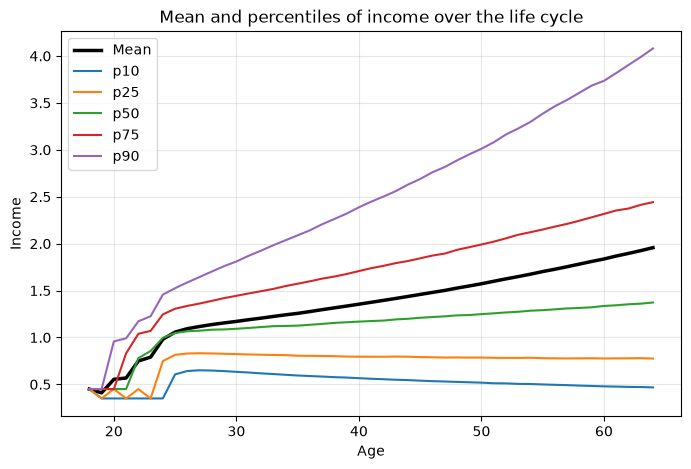

,mean,p10,p25,p50,p75,p90
age,,,,,,
18,0.4500,0.4500,0.4500,0.4500,0.4500,0.4500
25,1.0576,0.6065,0.8149,1.0476,1.3062,1.5250
35,1.2568,0.5947,0.8052,1.1260,1.5728,2.0886
45,1.4586,0.5396,0.7907,1.2099,1.8436,2.6891
64,1.9571,0.4678,0.7754,1.3729,2.4420,4.0804


In [4]:
percentiles = [10, 25, 50, 75, 90]
by_age = baseline.groupby("age")["income"]
stats_by_age = pd.DataFrame({"mean": by_age.mean()})
for p in percentiles:
    stats_by_age[f"p{p}"] = by_age.quantile(p / 100)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(stats_by_age.index, stats_by_age["mean"], color="black", lw=2.5, label="Mean")
for p in percentiles:
    ax.plot(stats_by_age.index, stats_by_age[f"p{p}"], lw=1.5, label=f"p{p}")
ax.set_xlabel("Age")
ax.set_ylabel("Income")
ax.set_title("Mean and percentiles of income over the life cycle")
ax.legend()
plt.show()

stats_by_age.loc[[18, 25, 35, 45, 64]]


The kink at age 19 (short education finishing) and the further kinks at ages
21 and 23 (medium and long education finishing) are clearly visible: income
jumps up sharply from the student grant $y_{SU}=0.45$ to the entry human
capital $h_{0,e}$ once each education group enters the labour market, then
grows on average over the life cycle as human capital accumulates, while the
spread between percentiles widens — a textbook age-earnings profile.


## 2.2.3 Shape of the distribution at ages 25, 35, 45 and 60

Histograms at ages 25, 35, 45, 60 show the full shape of the distribution,
not just a few percentile points.

**How:** Loop over the four ages, filter `baseline["age"] == age`, plot each
income column with `ax.hist(...)` on a 2x2 grid; `scipy.stats.skew` added to
each title.


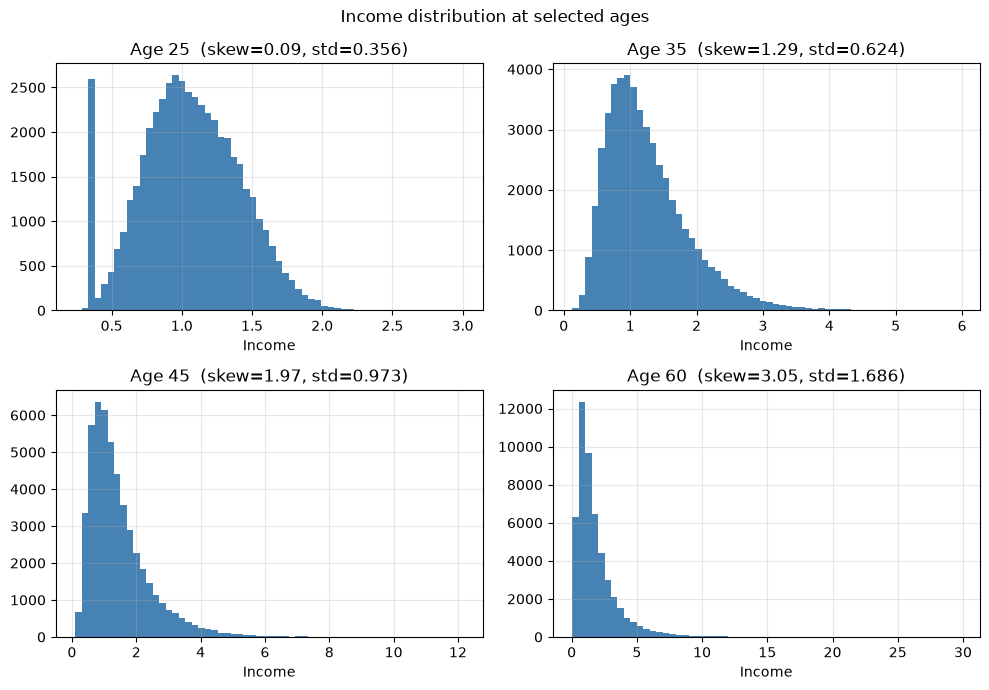

In [5]:
ages_to_plot = [25, 35, 45, 60]
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False)
for ax, age in zip(axes.ravel(), ages_to_plot):
    x = baseline.loc[baseline["age"] == age, "income"]
    ax.hist(x, bins=60, color="steelblue", edgecolor="none")
    ax.set_title(f"Age {age}  (skew={stats.skew(x):.2f}, std={x.std():.3f})")
    ax.set_xlabel("Income")
fig.suptitle("Income distribution at selected ages")
fig.tight_layout()
plt.show()


At **age 25** most people have only recently entered the labour market: the
distribution is fairly concentrated and already shows the three humps coming
from the three education-specific starting levels of human capital.  As age
increases to **35 and 45**, human-capital shocks and differential growth
rates $D_e$ compound, so the distribution spreads out and its right tail
gets longer (higher skewness) — high earners pull further ahead. By **age
60**, the distribution is at its widest and most right-skewed: decades of
compounding lognormal shocks combined with unemployment scarring (spells of
depreciation for the unlucky) produce substantial dispersion, while the bulk
of the mass still sits at moderate income levels.


## 2.3 The Gini coefficient — implementation and validation

We implement `gini()` in `life_cycle.py` using the standard rank-based
formula and validate it against two known closed forms:

- Gini of $U(0,1)$ is exactly $1/3$.
- Gini of a lognormal distribution with underlying standard deviation
  $s$ is $2\Phi(s/\sqrt{2}) - 1$.

**How:** Draw 2,000,000 draws with `rng.uniform(...)` / `rng.lognormal(...)`,
run through `gini()`, compare to the closed-form value (`scipy.stats.norm.cdf`
for the lognormal case).

In [6]:
rng = np.random.default_rng(0)

u = rng.uniform(0, 1, size=2_000_000)
print(f"Gini(Uniform[0,1])      = {gini(u):.5f}   (theory: {1/3:.5f})")

s = 0.8
lognorm_draws = rng.lognormal(mean=0.0, sigma=s, size=2_000_000)
theory = 2 * stats.norm.cdf(s / np.sqrt(2)) - 1
print(f"Gini(Lognormal, s={s})  = {gini(lognorm_draws):.5f}   (theory: {theory:.5f})")

Gini(Uniform[0,1])      = 0.33329   (theory: 0.33333)
Gini(Lognormal, s=0.8)  = 0.42839   (theory: 0.42839)



### 2.3.1 Gini coefficient for the full sample, and the Lorenz curve

"Full sample" pools every simulated (individual, age) observation, i.e. the
entire panel of `N * T` income observations.

**How:** `gini(baseline["income"].values)`; `lorenz_curve()` (from
`life_cycle.py`) sorts incomes ascending and returns cumulative
population/income shares, plotted against the 45° equality line.

Gini coefficient, full pooled sample: 0.3699


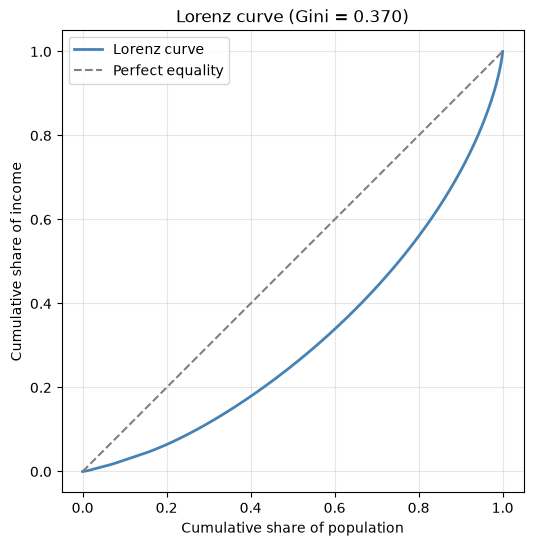

In [7]:
g_pooled = gini(baseline["income"].values)
print(f"Gini coefficient, full pooled sample: {g_pooled:.4f}")

pop_share, income_share = lorenz_curve(baseline["income"].values)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(pop_share, income_share, color="steelblue", lw=2, label="Lorenz curve")
ax.plot([0, 1], [0, 1], color="grey", ls="--", label="Perfect equality")
ax.set_xlabel("Cumulative share of population")
ax.set_ylabel("Cumulative share of income")
ax.set_title(f"Lorenz curve (Gini = {g_pooled:.3f})")
ax.legend()
ax.set_aspect("equal")
plt.show()


### 2.3.2 Gini coefficient by age vs. the pooled Gini


**How:** `groupby("age")["income"].apply(lambda s: gini(s.values))` runs
`gini()` per age instead of once on the whole panel; plotted against a
horizontal line at the pooled value.

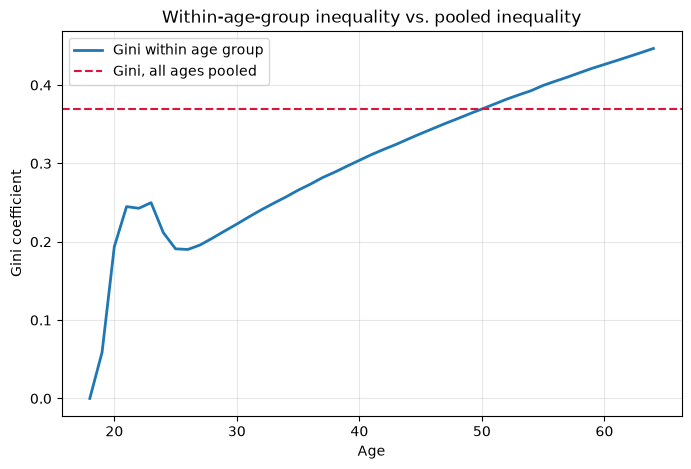

Pooled Gini:                0.3699
Average within-age Gini:    0.3040
Gini at age 25 / 45 / 64:   0.1909 / 0.3379 / 0.4467


In [8]:
gini_by_age = baseline.groupby("age")["income"].apply(lambda s: gini(s.values))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gini_by_age.index, gini_by_age.values, lw=2, label="Gini within age group")
ax.axhline(g_pooled, color="crimson", ls="--", label="Gini, all ages pooled")
ax.set_xlabel("Age")
ax.set_ylabel("Gini coefficient")
ax.set_title("Within-age-group inequality vs. pooled inequality")
ax.legend()
plt.show()

print(f"Pooled Gini:                {g_pooled:.4f}")
print(f"Average within-age Gini:    {gini_by_age.mean():.4f}")
print(f"Gini at age 25 / 45 / 64:   {gini_by_age[25]:.4f} / {gini_by_age[45]:.4f} / {gini_by_age[64]:.4f}")


The **pooled** Gini coefficient is noticeably higher than the **within-age**
Gini coefficients at every single age. This is a standard result: pooling
observations across ages adds a purely mechanical, "between-group" source
of inequality — the systematic age-earnings profile itself (education
premia, human-capital accumulation over the life cycle, the low-income
schooling years) — on top of the genuine within-cohort inequality that
individuals of the same age experience. Within-age inequality itself rises
steadily with age as idiosyncratic shocks and unemployment scarring
compound over the life cycle, consistent with the widening histograms in
2.2.3.



## 2.4 What drives inequality? Switching off model components

We re-simulate the model four times, each time switching off one channel
(holding the random seed fixed so the comparison is as clean as possible),
and compare the resulting Gini coefficients — both pooled over all ages and
within a single age group (age 45, a "prime-age" cross-section) — to the
baseline.

**How:** `Params` is a dataclass with these flags defaulting to `False`. We
build a dict of `{name: Params(...)}`, loop over it calling `simulate(p)`,
and collect pooled and age-45 Gini into a `decomp` DataFrame (one row per
scenario). Inside `simulate()` (in `life_cycle.py`), each flag gates a small
`if`/`else` at the point where that term is applied, e.g.
`psi = np.ones(N) if params.shut_shocks else rng.lognormal(...)` 
The loop itself is never duplicated. This keeps the model in one place (DRY) instead
of copy-pasting the whole simulation per scenario, which is why we
parametrize rather than subclass.

In [9]:
AGE_GROUP = 45

variants = {
    "Baseline": Params(),
    "No educational differences": Params(shut_education_hetero=True),
    "No human-capital shocks": Params(shut_shocks=True),
    "No depreciation while unemployed": Params(shut_depreciation=True),
    "No unemployment": Params(shut_unemployment=True),
}

rows = []
sims = {}
for name, p in variants.items():
    df = simulate(p)
    sims[name] = df
    g_all = gini(df["income"].values)
    g_age = gini(df.loc[df["age"] == AGE_GROUP, "income"].values)
    rows.append({"variant": name, "gini_pooled": g_all, "gini_age45": g_age})

decomp = pd.DataFrame(rows).set_index("variant")
decomp["delta_pooled_vs_baseline"] = decomp["gini_pooled"] - decomp.loc["Baseline", "gini_pooled"]
decomp["delta_age45_vs_baseline"] = decomp["gini_age45"] - decomp.loc["Baseline", "gini_age45"]
decomp

,gini_pooled,gini_age45,delta_pooled_vs_baseline,delta_age45_vs_baseline
variant,,,,
Baseline,0.3699,0.3379,0.0000,0.0000
No educational differences,0.3148,0.2892,-0.0551,-0.0487
No human-capital shocks,0.2709,0.2111,-0.0990,-0.1268
No depreciation while unemployed,0.3768,0.3263,0.0069,-0.0116
No unemployment,0.3724,0.3237,0.0025,-0.0142


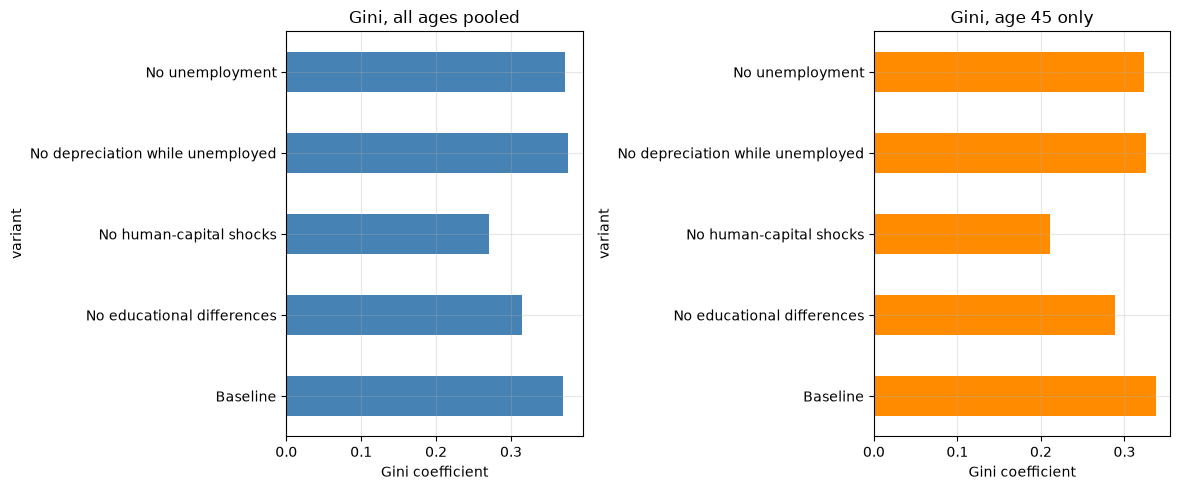

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
decomp["gini_pooled"].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Gini, all ages pooled")
axes[0].set_xlabel("Gini coefficient")
decomp["gini_age45"].plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title(f"Gini, age {AGE_GROUP} only")
axes[1].set_xlabel("Gini coefficient")
fig.tight_layout()
plt.show()

**Which mechanism matters most?**

- **Human-capital shocks are by far the biggest driver**, pooled and within
  age 45: removing them cuts the pooled Gini from ~0.37 to ~0.27. This is
  the channel that spreads out otherwise-identical people (same age,
  education, employment history).
- **Education is the second-largest driver.** It generates a persistent gap
  in starting human capital and its growth rate, so — unlike a simple
  location shift — it still shows up *within* a single age group, not just
  between age groups.
- **Unemployment and depreciation barely move the Gini** — if anything,
  removing them makes incomes *very slightly* more unequal. This is the
  surprising result: cutting unemployment doesn't just remove a low-income
  state, it also raises everyone's human-capital growth path (compounding
  at the employed rate $(1+D_e)$ instead of occasionally shrinking at
  $(1-\delta)$). Average income rises ~20%, and absolute dispersion rises
  by a similar proportion — so *relative* dispersion (the Gini) is roughly
  unchanged. Unemployment redistributes *who* is low-income more than it
  changes *how unequal* incomes are overall.

Pooled and within-age-45 effects point the same direction for every
channel, but education's pooled effect is larger than its within-age
effect, since it also adds a between-age effect via the age-profile from
2.3.2.


## 2.5 Extension: adding disability risk

As an additional, empirically-motivated source of risk we add a small
per-period probability $\pi_{dis}$ that a working individual becomes
**permanently disabled**. A disabled individual exits normal employment for
good, stops accumulating human capital, and receives a flat, low
disability benefit $y_{dis}$ for the remainder of their working life. This
is implemented directly in `life_cycle.simulate()` via the `pi_dis` and
`y_dis` parameters (see the module docstring).

This channel is qualitatively different from the existing ones: it is a
rare, permanent, absorbing bad shock (rather than a persistent-but-reversible
Markov state like unemployment, or a continuous multiplicative shock like
$\psi$), so we expect it to primarily fatten the *left tail* of the income
distribution rather than widen the whole distribution symmetrically.

**How:** `pi_dis` and `y_dis` are new fields on `Params` (default 0, so the
baseline is unaffected). In `simulate()` (in `life_cycle.py`), each working,
non-disabled person draws a Bernoulli event with probability `pi_dis` each
period; once triggered, a `disabled` flag is set permanently, income is
fixed at `y_dis`, and human-capital updates are skipped going forward. Run
with `Params(pi_dis=0.0015, y_dis=0.30)` and compared to baseline.

In [11]:
ext_params = Params(pi_dis=0.0015, y_dis=0.30)
ext = simulate(ext_params)

g_ext_pooled = gini(ext["income"].values)
g_ext_age45 = gini(ext.loc[ext["age"] == AGE_GROUP, "income"].values)

print(f"Baseline Gini   -- pooled: {g_pooled:.4f}   age {AGE_GROUP}: {gini_by_age[AGE_GROUP]:.4f}")
print(f"With disability -- pooled: {g_ext_pooled:.4f}   age {AGE_GROUP}: {g_ext_age45:.4f}")

disabled_share_by_age = ext.groupby("age")["disabled"].mean()
print(f"\nShare disabled by age 64: {disabled_share_by_age.loc[64]:.3%}")

Baseline Gini   -- pooled: 0.3699   age 45: 0.3379
With disability -- pooled: 0.3802   age 45: 0.3542

Share disabled by age 64: 6.372%


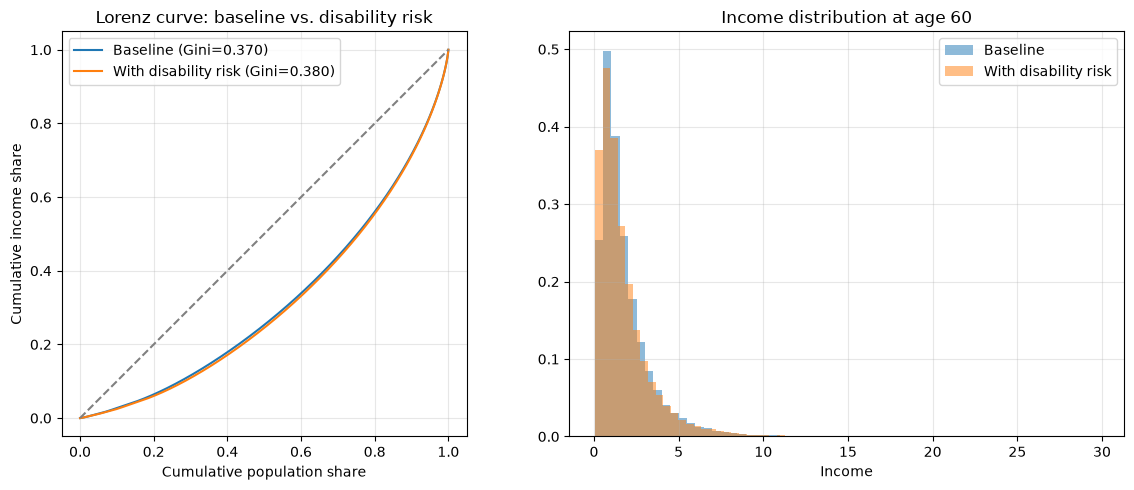

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pop_b, inc_b = lorenz_curve(baseline["income"].values)
pop_e, inc_e = lorenz_curve(ext["income"].values)
axes[0].plot(pop_b, inc_b, label=f"Baseline (Gini={g_pooled:.3f})")
axes[0].plot(pop_e, inc_e, label=f"With disability risk (Gini={g_ext_pooled:.3f})")
axes[0].plot([0, 1], [0, 1], color="grey", ls="--")
axes[0].set_title("Lorenz curve: baseline vs. disability risk")
axes[0].set_xlabel("Cumulative population share")
axes[0].set_ylabel("Cumulative income share")
axes[0].legend()
axes[0].set_aspect("equal")

x_b = baseline.loc[baseline["age"] == 60, "income"]
x_e = ext.loc[ext["age"] == 60, "income"]
axes[1].hist(x_b, bins=60, alpha=0.5, label="Baseline", density=True)
axes[1].hist(x_e, bins=60, alpha=0.5, label="With disability risk", density=True)
axes[1].set_title("Income distribution at age 60")
axes[1].set_xlabel("Income")
axes[1].legend()

fig.tight_layout()
plt.show()

As expected, disability risk raises the Gini coefficient, both pooled and
at age 45, by adding a new low-income mass point ($y_{dis}=0.30$) that a
small, growing share of the cohort falls into with age. This shows up as
extra mass at the low end of the age-60 histogram, and as a small outward
bulge near the bottom of the Lorenz curve — the "left-tail fattening"
signature of a rare, permanent, one-sided shock. This is qualitatively
different from the symmetric, multiplicative spreading from human-capital
shocks in Section 2.4 (still the largest driver overall): disability adds a
smaller, more localized source of dispersion concentrated at the bottom.